# 01. ESS 배터리 데이터 점검 및 탐색적 데이터 분석 (EDA)

## 1. 분석 개요 및 목적
- **데이터셋**: MIT-Stanford Battery Dataset (Severson et al., Nature Energy 2019)
- **대상 배치**:
  - Batch 1 (`2017-05-12`): 모델 학습 및 Hold-out 검증 (46 셀)
  - Batch 2 (`2018-02-20`): 최종 테스트 (47 셀)
  - Batch 3 (`2018-04-12`): 추가 비교 분석 (46 셀)
- **오늘의 5대 핵심 질문**:
  1. Cycle Life 분포 (장수명 >1000, 단수명 <500 비율 및 이상 셀 확인)
  2. 방전 용량 열화 곡선 (열화 속도, Knee-point 분석)
  3. $\Delta Q_{100-10}(V)$ 곡선 특성 (장·단수명 셀 구분 신호)
  4. 충전 프로토콜 (C-rate) 영향
  5. 초기 100/5 사이클 신호와 수명의 상관관계

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 프로젝트 루트 경로 등록
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

from src.preprocess import load_batch_summary

# 한글 폰트 및 스타일 설정
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'AppleGothic' if sys.platform == 'darwin' else 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

DATA_DIR = os.path.join(project_root, 'data')
print(f"Data Directory: {DATA_DIR}")

Data Directory: /Users/skala_yh/DS_miniproject/data


## 2. 배치별 데이터 로드 및 점검표 작성

In [3]:
b1_path = os.path.join(DATA_DIR, '2017-05-12_batchdata_updated_struct_errorcorrect.mat')
b2_path = os.path.join(DATA_DIR, '2018-02-20_batchdata_updated_struct_errorcorrect.mat')
b3_path = os.path.join(DATA_DIR, '2018-04-12_batchdata_updated_struct_errorcorrect.mat')

df_b1 = load_batch_summary(b1_path, 'Batch1')
df_b2 = load_batch_summary(b2_path, 'Batch2')
df_b3 = load_batch_summary(b3_path, 'Batch3')

df_all = pd.concat([df_b1, df_b2, df_b3], ignore_index=True)

# 배치별 기초 점검 요약
summary_table = df_all.groupby('batch').agg(
    cell_count=('cell_id', 'count'),
    life_min=('cycle_life', 'min'),
    life_mean=('cycle_life', 'mean'),
    life_max=('cycle_life', 'max'),
    unique_policies=('policy', 'nunique')
).reset_index()

display(summary_table)

,batch,cell_count,life_min,life_mean,life_max,unique_policies
0,Batch1,46,534.0,844.717391,1227.0,23
1,Batch2,47,392.0,565.743590,1186.0,20
2,Batch3,46,541.0,1059.659091,1935.0,8


## 3. 질문 1: Cycle Life 분포 비교

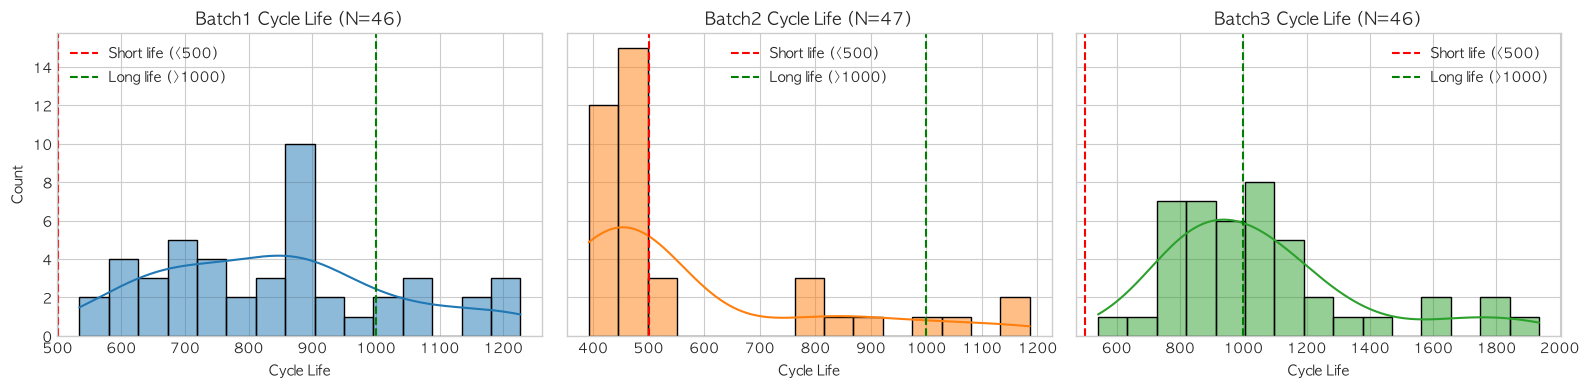

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
batches = ['Batch1', 'Batch2', 'Batch3']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for ax, b, c in zip(axes, batches, colors):
    sub = df_all[df_all['batch'] == b]
    sns.histplot(sub['cycle_life'], kde=True, ax=ax, color=c, bins=15)
    ax.axvline(500, color='red', linestyle='--', label='Short life (<500)')
    ax.axvline(1000, color='green', linestyle='--', label='Long life (>1000)')
    ax.set_title(f"{b} Cycle Life (N={len(sub)})")
    ax.set_xlabel('Cycle Life')
    ax.legend()

plt.tight_layout()
plt.show()